#### **Selección de Entorno y Complementos**

In [ ]:
# CONFIGURACIÓN DE ENTORNO

# Si no cuenta con Google Drive instalado, cambie a True SOLO si desea ejecutar este notebook en Google Colab y quiere usar la conexión a Drive.

# En caso seleccione True, deberá configurar el Kernel para trabajar con Colab y Drive antes de ejecutar esta celda, además deberá especificar 
# el nombre y ruta de su archivo en la celda "Carga de Imagen"

# Si estás en VS Code con kernel local, mantenga en False.

COLAB = False

In [ ]:
# INSTALACIÓN DE DEPENDENCIAS

# Tesseract como motor OCR debe instalarse a nivel de sistema operativo.

if COLAB:
    !apt-get install tesseract-ocr tesseract-ocr-spa -y
else:
    #   Tesseract debe instalarse manualmente según tu SO:
    #   Windows -> https://github.com/UB-Mannheim/tesseract/wiki
    #   Mac     -> brew install tesseract tesseract-lang
    #   Linux   -> sudo apt-get install tesseract-ocr tesseract-ocr-spa
    print("Modo local: asegúrate de tener Tesseract instalado en tu sistema.")

# Librerías de Python
!pip install pytesseract opencv-python numpy matplotlib -q

Modo local: asegúrate de tener Tesseract instalado en tu sistema.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import urllib.request
import pytesseract


# CONFIGURACIÓN AUTOMÁTICA DE TESSERACT Y ESPAÑOL

# 1. Localizar el ejecutable de Tesseract en el sistema
ruta_tesseract = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
if not os.path.exists(ruta_tesseract):
    ruta_usuario = os.path.expanduser(r"~\AppData\Local\Programs\Tesseract-OCR\tesseract.exe")
    if os.path.exists(ruta_usuario):
        ruta_tesseract = ruta_usuario

if os.path.exists(ruta_tesseract):
    pytesseract.pytesseract.tesseract_cmd = ruta_tesseract
    print(f"Tesseract encontrado en: {ruta_tesseract}")
else:
    print("Tesseract no está instalado en el sistema.")

# 2. Configurar una carpeta tessdata local en el perfil del usuario (evita permisos de administrador)
carpeta_tessdata_usuario = os.path.expanduser(r"~\AppData\Local\Tesseract-OCR\tessdata")
os.makedirs(carpeta_tessdata_usuario, exist_ok=True)

ruta_spa = os.path.join(carpeta_tessdata_usuario, "spa.traineddata")

# 3. Descargar automáticamente el archivo de idioma español si no existe
if not os.path.exists(ruta_spa):
    print("Descargando el paquete de idioma español (spa.traineddata) desde GitHub...")
    url_spa = "https://github.com/tesseract-ocr/tessdata/raw/main/spa.traineddata"
    try:
        urllib.request.urlretrieve(url_spa, ruta_spa)
        print("¡Archivo 'spa.traineddata' descargado y configurado con éxito!")
    except Exception as e:
        print(f"No se pudo descargar el idioma automáticamente: {e}")
else:
    print("¡El paquete de idioma español ya está listo en el sistema!")

# 4. Establecer la variable de entorno para que Tesseract reconozca la ruta del idioma
os.environ["TESSDATA_PREFIX"] = carpeta_tessdata_usuario

Tesseract encontrado en: C:\Program Files\Tesseract-OCR\tesseract.exe
¡El paquete de idioma español ya está listo en el sistema!


In [ ]:
# CONEXIÓN A GOOGLE DRIVE VÍA COLAB

# Este bloque solo se ejecuta si COLAB = True en la Celda 1.
# Requiere configurar el Kernel para trabajar con Colab

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive montado con éxito.")
else:
    print("Bloque desactivado (COLAB = False). No se requiere para el modo local.")

Bloque desactivado (COLAB = False). No se requiere para el modo local.


#### **Librerías**

In [ ]:
# LIBRERÍAS Y FUNCIONES

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

if COLAB:
    from google.colab import drive
    from google.colab.patches import cv2_imshow
else:
    # cv2_imshow es una función exclusiva de Colab (google.colab.patches).
    # La recreamos aquí con matplotlib para que los bloques de código que 
    # la usen sigan funcionando igual en modo local.
    def cv2_imshow(img):
        if len(img.shape) == 2:  # imagen en escala de grises
            plt.imshow(img, cmap='gray')
        else:  # imagen a color (BGR -> RGB)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

# Función auxiliar para la información de la imagen
def InfoImg(img):
    print('size:', img.shape)
    print('max val:', np.max(img))
    print('min val:', np.min(img))

### **Carga de Imagen**

Imagen cargada con éxito desde:
C:/Users/calde/OneDrive/Documentos/Python/Colab/Extra/Imágenes PF/prueba0.jpg


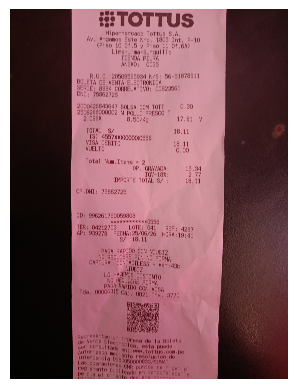

In [ ]:
# CARGA DE IMAGEN

img = None

if COLAB:
    # Modo Colab
    # Modifique el nombre y ruta de su archivo en caso 'COLAB = True' de la primera celda
    # Nombre específico de su archivo en Google Drive
    name = 'prueba0.jpg'
    # Ruta específica de su archivo en Google Drive
    ruta = f'/content/drive/MyDrive/PDS_Images/{name}'
    
    file_bytes = np.fromfile(ruta, dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    if img is not None:
        print(f"Imagen '{name}' cargada con éxito desde Google Drive.")
    else:
        print(f"Error: No se encontró la imagen en la ruta:\n{ruta}")

else:
    # Modo local

    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    ruta = filedialog.askopenfilename(
        title="Selecciona la imagen del recibo/factura",
        filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp *.tiff")]
    )
    root.destroy()

    if ruta:
        file_bytes = np.fromfile(ruta, dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

        if img is not None:
            print(f"Imagen cargada con éxito desde:\n{ruta}")
            cv2_imshow(img)
        else:
            print(f"Error: no se pudo leer la imagen en:\n{ruta}")
    else:
        print("No se seleccionó ningún archivo.")